In [0]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [0]:
# Load the cleaned data
df = spark.table("car_price_cleaned")
df_pd = df.toPandas()

print(f"Dataset shape: {df_pd.shape}")
print(f"\nColumns: {df_pd.columns.tolist()}")
print(f"\nFirst few rows:")
display(df_pd.head())

Dataset shape: (205, 28)

Columns: ['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'doornumber_numeric', 'cylindernumber_numeric']

First few rows:


car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,doornumber_numeric,cylindernumber_numeric
1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,2,4
2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,2,4
3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,2,6
4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950.0,4,4
5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450.0,4,5


In [0]:
# Dataset Overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal Records: {df_pd.shape[0]}")
print(f"Total Features: {df_pd.shape[1]}")

print(f"\n\nData Types:")
print(df_pd.dtypes)

print(f"\n\nMemory Usage:")
print(df_pd.memory_usage(deep=True))

print(f"\n\nNumerical Columns: {len(df_pd.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Categorical Columns: {len(df_pd.select_dtypes(include=['object']).columns)}")

DATASET OVERVIEW

Total Records: 205
Total Features: 28


Data Types:
car_ID                      int64
symboling                   int64
CarName                    object
fueltype                   object
aspiration                 object
doornumber                 object
carbody                    object
drivewheel                 object
enginelocation             object
wheelbase                 float64
carlength                 float64
carwidth                  float64
carheight                 float64
curbweight                  int64
enginetype                 object
cylindernumber             object
enginesize                  int64
fuelsystem                 object
boreratio                 float64
stroke                    float64
compressionratio          float64
horsepower                  int64
peakrpm                     int64
citympg                     int64
highwaympg                  int64
price                     float64
doornumber_numeric          int64
cylindernumb

In [0]:
# Statistical Summary - Numerical Variables
print("=" * 60)
print("STATISTICAL SUMMARY - NUMERICAL VARIABLES")
print("=" * 60)

display(df_pd.describe())

# Additional statistics
print("\n\nSkewness:")
print(df_pd.select_dtypes(include=['int64', 'float64']).skew())

print("\n\nKurtosis:")
print(df_pd.select_dtypes(include=['int64', 'float64']).kurtosis())

STATISTICAL SUMMARY - NUMERICAL VARIABLES


car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,doornumber_numeric,cylindernumber_numeric
205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0,205.0
103.0,0.8341463414634146,98.75658536585367,174.04926829268288,65.90780487804878,53.72487804878049,2555.5658536585365,126.90731707317073,3.329756097560975,3.255414634146341,10.142536585365855,104.1170731707317,5125.121951219512,25.21951219512195,30.75121951219512,13276.710570731706,3.1219512195121952,4.380487804878049
59.32256456582661,1.2453068281055297,6.021775685025571,12.33728852655518,2.145203852687183,2.4435219699049036,520.6802035016387,41.64269343817984,0.27084370542622926,0.31359701376080407,3.972040321863298,39.54416680936116,476.98564305694634,6.542141653001622,6.886443130941824,7988.85233174315,0.9949658076502494,1.0808537638918492
1.0,-2.0,86.6,141.1,60.3,47.8,1488.0,61.0,2.54,2.07,7.0,48.0,4150.0,13.0,16.0,5118.0,2.0,2.0
52.0,0.0,94.5,166.3,64.1,52.0,2145.0,97.0,3.15,3.11,8.6,70.0,4800.0,19.0,25.0,7788.0,2.0,4.0
103.0,1.0,97.0,173.2,65.5,54.1,2414.0,120.0,3.31,3.29,9.0,95.0,5200.0,24.0,30.0,10295.0,4.0,4.0
154.0,2.0,102.4,183.1,66.9,55.5,2935.0,141.0,3.58,3.41,9.4,116.0,5500.0,30.0,34.0,16503.0,4.0,4.0
205.0,3.0,120.9,208.1,72.3,59.8,4066.0,326.0,3.94,4.17,23.0,288.0,6600.0,49.0,54.0,45400.0,4.0,12.0




Skewness:
car_ID                    0.000000
symboling                 0.211072
wheelbase                 1.050214
carlength                 0.155954
carwidth                  0.904003
carheight                 0.063123
curbweight                0.681398
enginesize                1.947655
boreratio                 0.020156
stroke                   -0.689705
compressionratio          2.610862
horsepower                1.405310
peakrpm                   0.075159
citympg                   0.663704
highwaympg                0.539997
price                     1.777678
doornumber_numeric       -0.247552
cylindernumber_numeric    2.817459
dtype: float64


Kurtosis:
car_ID                    -1.200000
symboling                 -0.676271
wheelbase                  1.017039
carlength                 -0.082895
carwidth                   0.702764
carheight                 -0.443812
curbweight                -0.042854
enginesize                 5.305682
boreratio                 -0.785042
stroke 

TARGET VARIABLE ANALYSIS: PRICE

Mean Price: $13,276.71
Median Price: $10,295.00
Std Deviation: $7,988.85
Min Price: $5,118.00
Max Price: $45,400.00

Price Range: $40,282.00


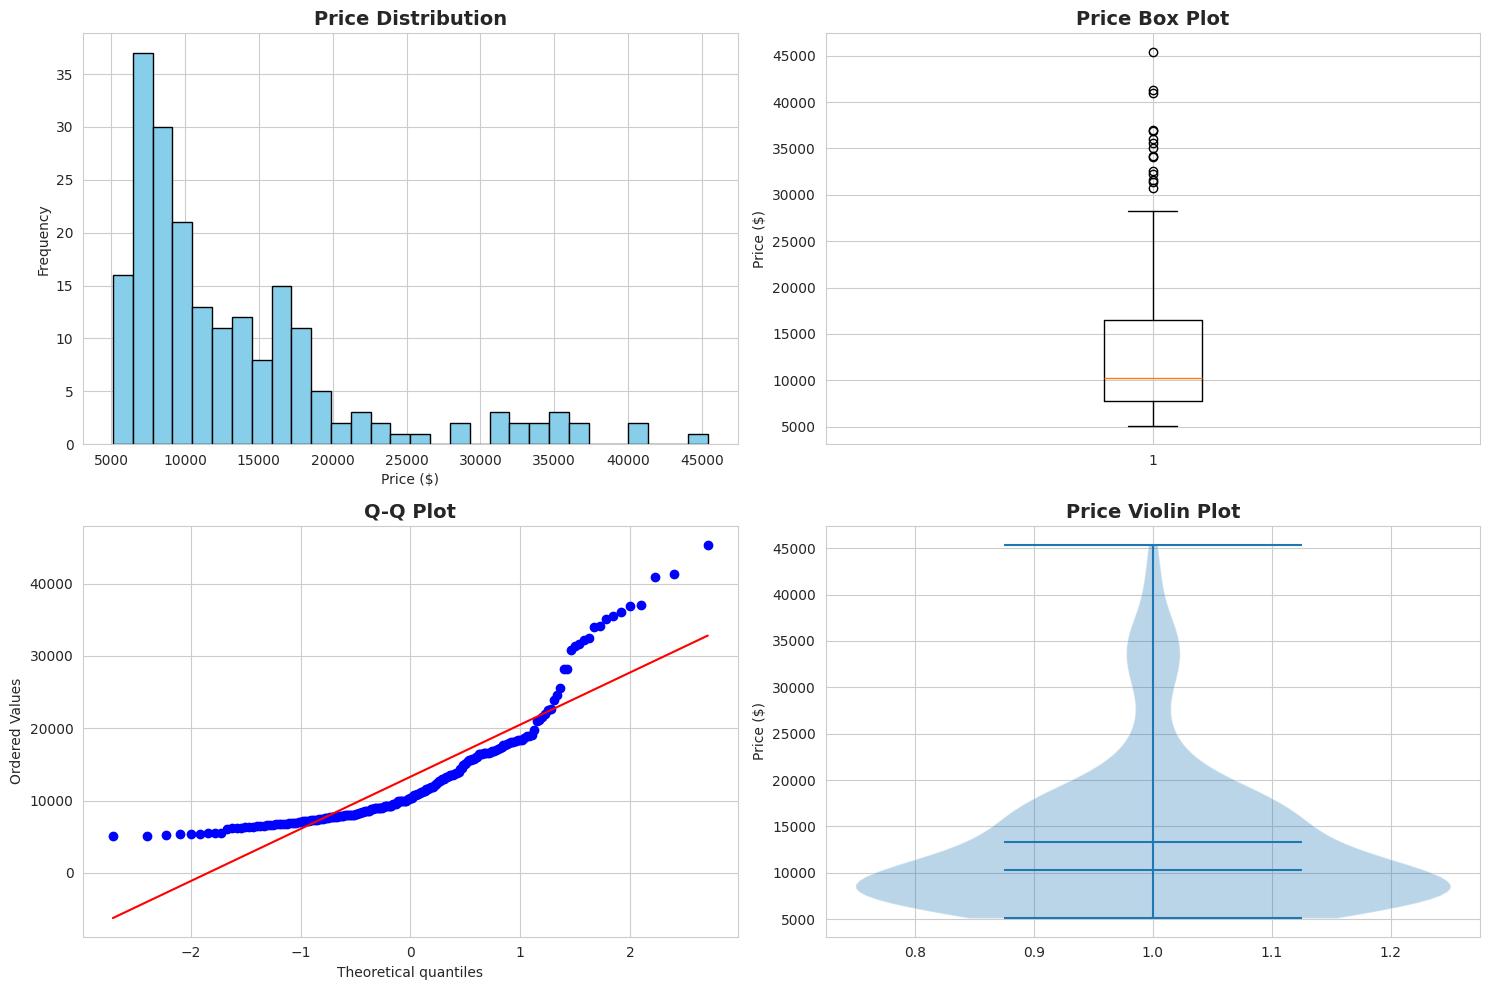

In [0]:
# Target Variable Analysis - Price
print("=" * 60)
print("TARGET VARIABLE ANALYSIS: PRICE")
print("=" * 60)

print(f"\nMean Price: ${df_pd['price'].mean():,.2f}")
print(f"Median Price: ${df_pd['price'].median():,.2f}")
print(f"Std Deviation: ${df_pd['price'].std():,.2f}")
print(f"Min Price: ${df_pd['price'].min():,.2f}")
print(f"Max Price: ${df_pd['price'].max():,.2f}")
print(f"\nPrice Range: ${df_pd['price'].max() - df_pd['price'].min():,.2f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution
axes[0, 0].hist(df_pd['price'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')

# Box plot
axes[0, 1].boxplot(df_pd['price'])
axes[0, 1].set_title('Price Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Price ($)')

# Q-Q plot (approximate)
from scipy import stats
stats.probplot(df_pd['price'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=14, fontweight='bold')

# Violin plot
axes[1, 1].violinplot([df_pd['price']], showmeans=True, showmedians=True)
axes[1, 1].set_title('Price Violin Plot', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Price ($)')

plt.tight_layout()
display(plt.show())

UNIVARIATE ANALYSIS - NUMERICAL FEATURES


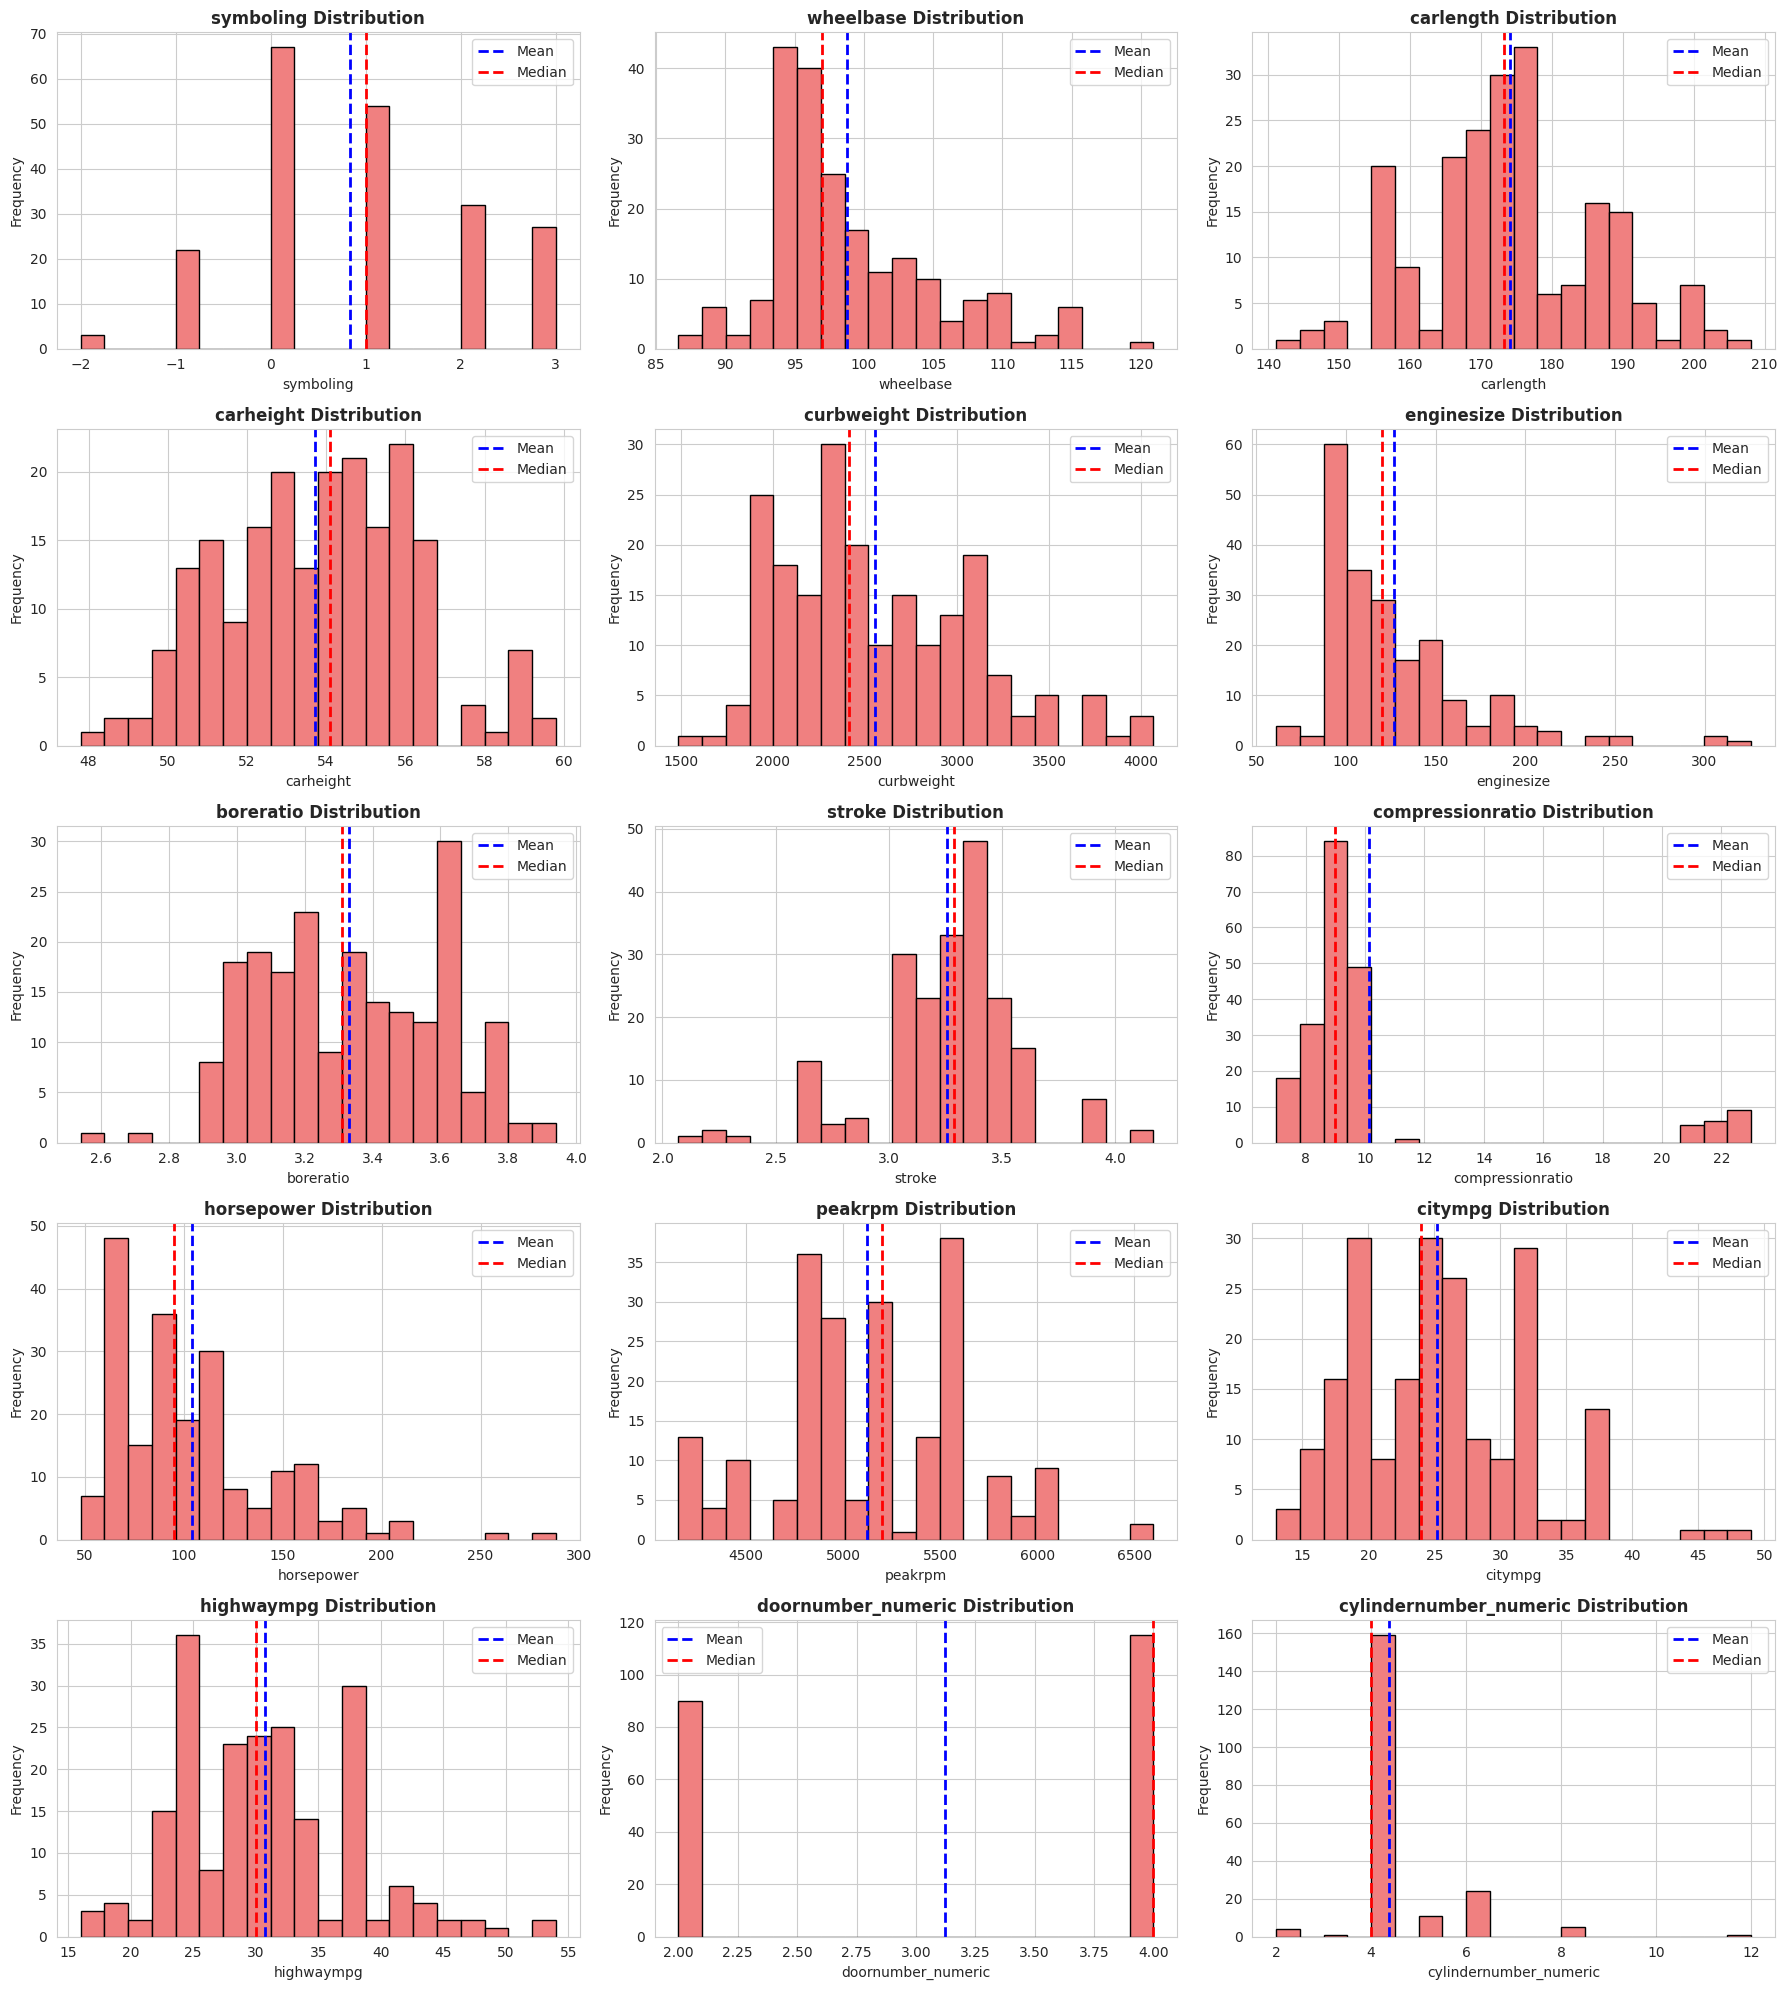

In [0]:
# Univariate Analysis - Numerical Features
print("=" * 60)
print("UNIVARIATE ANALYSIS - NUMERICAL FEATURES")
print("=" * 60)

# Select numerical columns (excluding ID and price)
numerical_cols = df_pd.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if 'ID' not in col and 'id' not in col and col != 'price']

# Plot distributions
num_cols = len(numerical_cols)
rows = (num_cols + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_pd[col], bins=20, edgecolor='black', color='lightcoral')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[idx].axvline(df_pd[col].mean(), color='blue', linestyle='--', linewidth=2, label='Mean')
    axes[idx].axvline(df_pd[col].median(), color='red', linestyle='--', linewidth=2, label='Median')
    axes[idx].legend()

# Hide empty subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
display(plt.show())

UNIVARIATE ANALYSIS - CATEGORICAL FEATURES

CARNAME:
CarName
toyota corona           6
toyota corolla          6
peugeot 504             6
subaru dl               4
mitsubishi mirage g4    3
                       ..
mazda glc 4             1
mazda rx2 coupe         1
maxda glc deluxe        1
maxda rx3               1
volvo 246               1
Name: count, Length: 147, dtype: int64
Unique values: 147

FUELTYPE:
fueltype
gas       185
diesel     20
Name: count, dtype: int64
Unique values: 2

ASPIRATION:
aspiration
std      168
turbo     37
Name: count, dtype: int64
Unique values: 2

DOORNUMBER:
doornumber
four    115
two      90
Name: count, dtype: int64
Unique values: 2

CARBODY:
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
Unique values: 5

DRIVEWHEEL:
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
Unique values: 3

ENGINELOCATION:
enginelocation
front    202
rear       3
Name: count

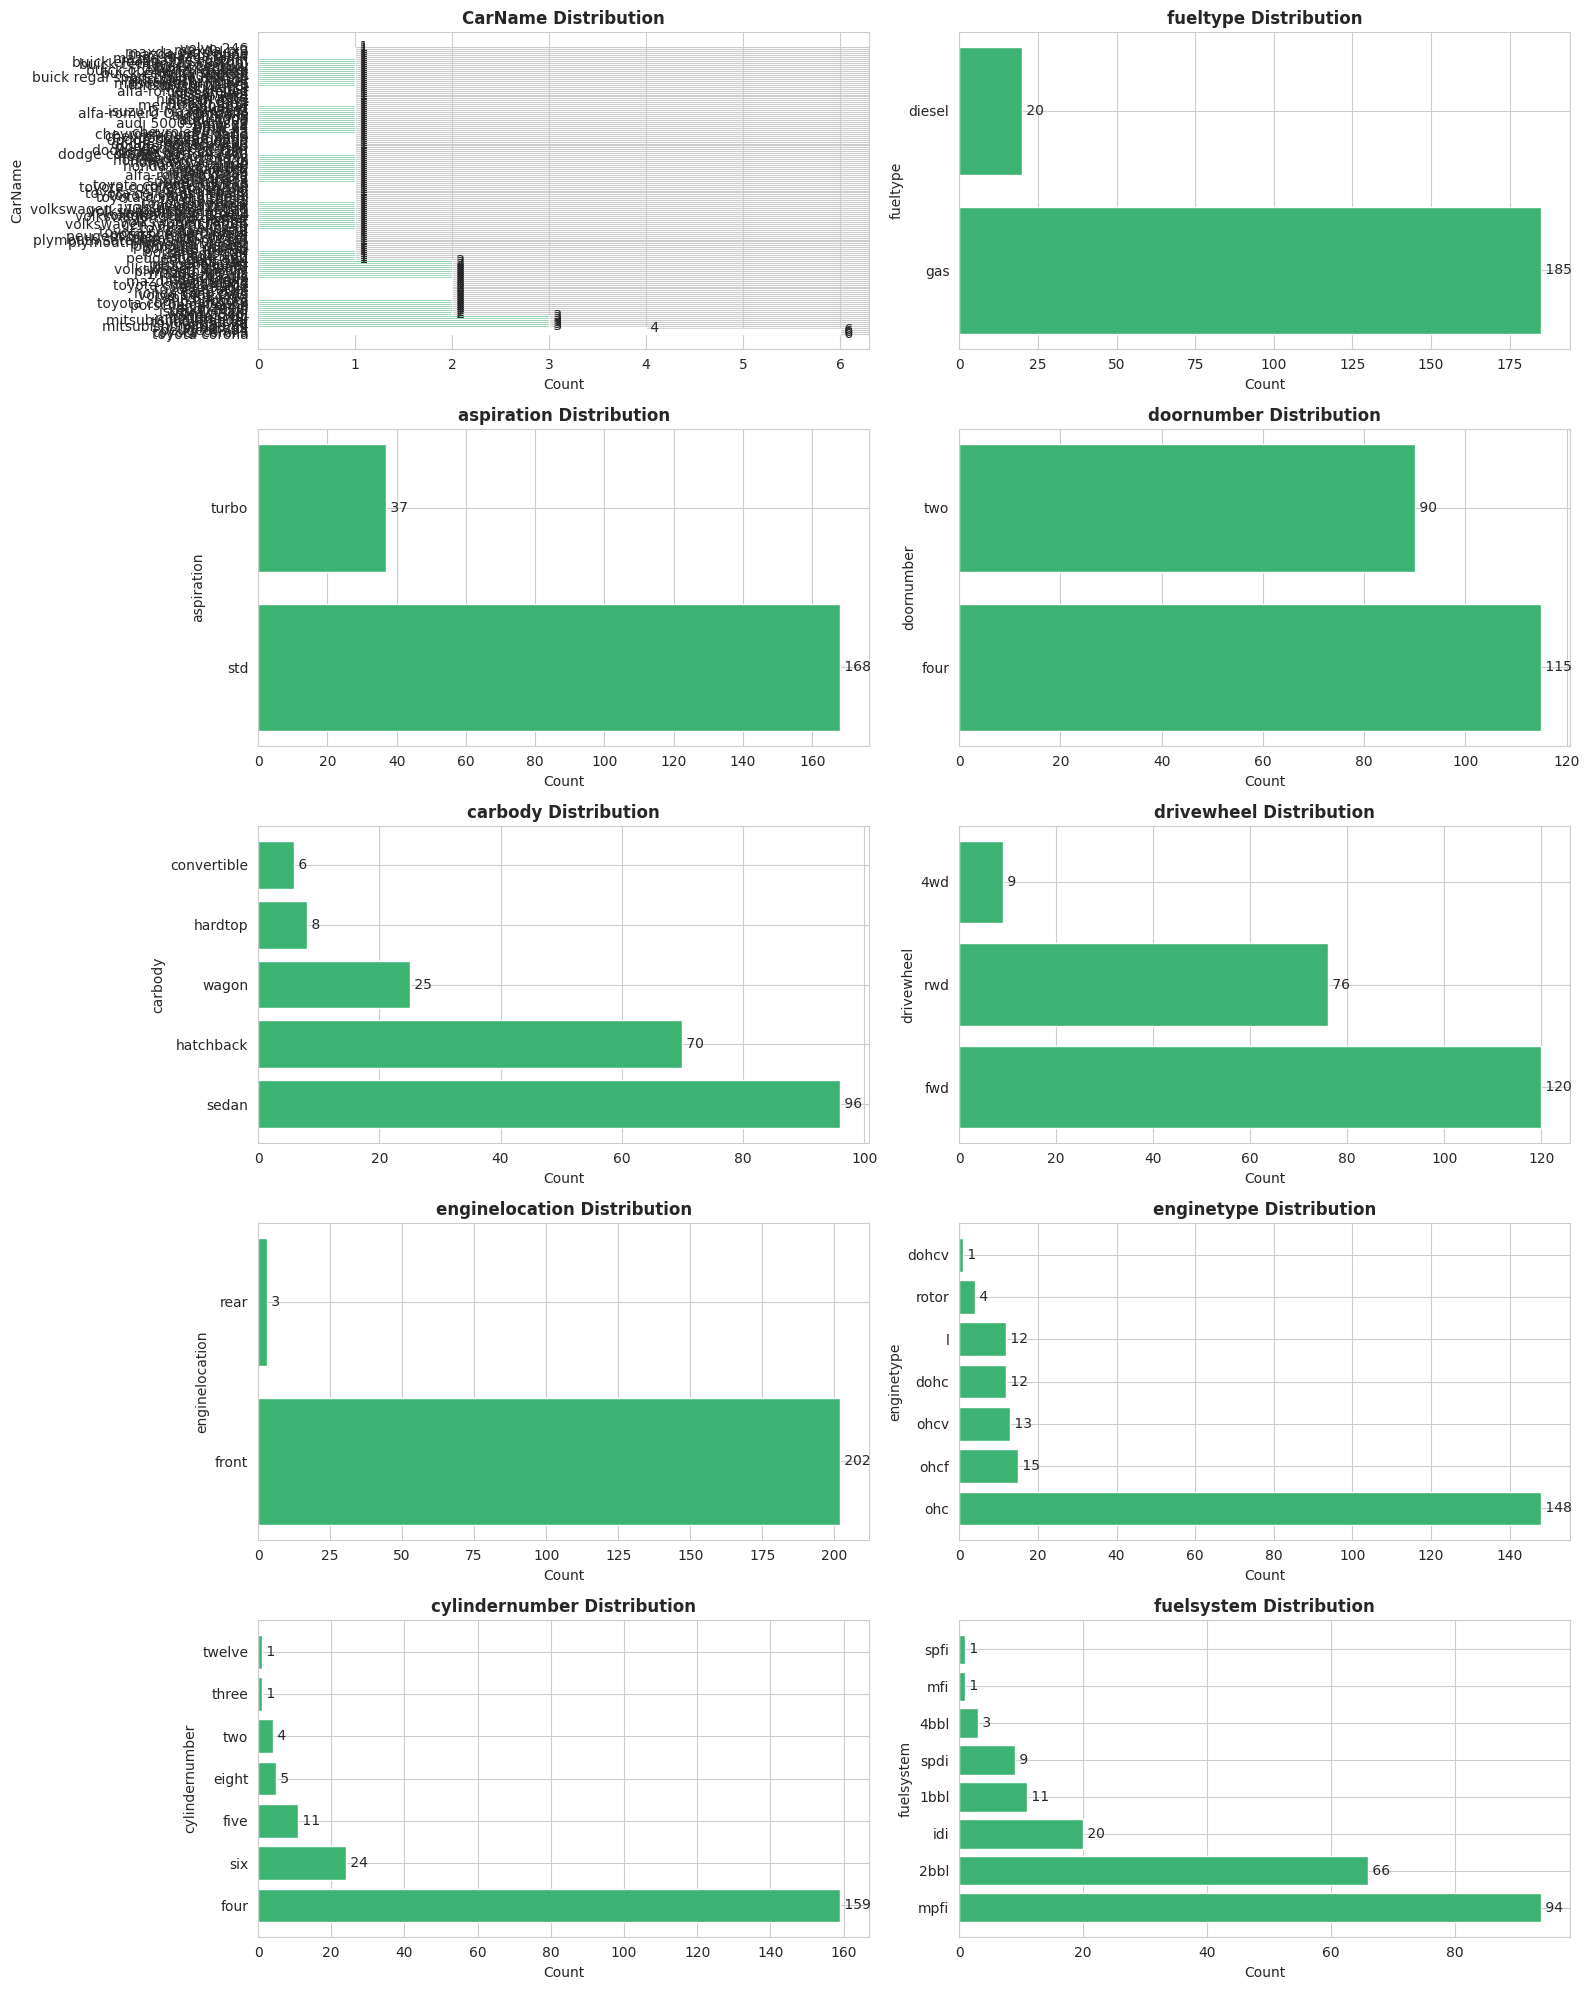

In [0]:
# Univariate Analysis - Categorical Features
print("=" * 60)
print("UNIVARIATE ANALYSIS - CATEGORICAL FEATURES")
print("=" * 60)

categorical_cols = df_pd.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df_pd[col].value_counts())
    print(f"Unique values: {df_pd[col].nunique()}")

# Plot categorical distributions
num_cats = len(categorical_cols)
rows = (num_cats + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df_pd[col].value_counts()
    axes[idx].barh(value_counts.index, value_counts.values, color='mediumseagreen')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Count')
    axes[idx].set_ylabel(col)
    
    # Add value labels
    for i, v in enumerate(value_counts.values):
        axes[idx].text(v, i, f' {v}', va='center')

# Hide empty subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
display(plt.show())

BIVARIATE ANALYSIS - PRICE VS NUMERICAL FEATURES

Correlation with Price:
enginesize                0.874145
curbweight                0.835305
horsepower                0.808139
cylindernumber_numeric    0.718305
carlength                 0.682920
wheelbase                 0.577816
boreratio                 0.553173
carheight                 0.119336
stroke                    0.079443
compressionratio          0.067984
doornumber_numeric        0.031835
symboling                -0.079978
peakrpm                  -0.085267
citympg                  -0.685751
highwaympg               -0.697599
Name: price, dtype: float64


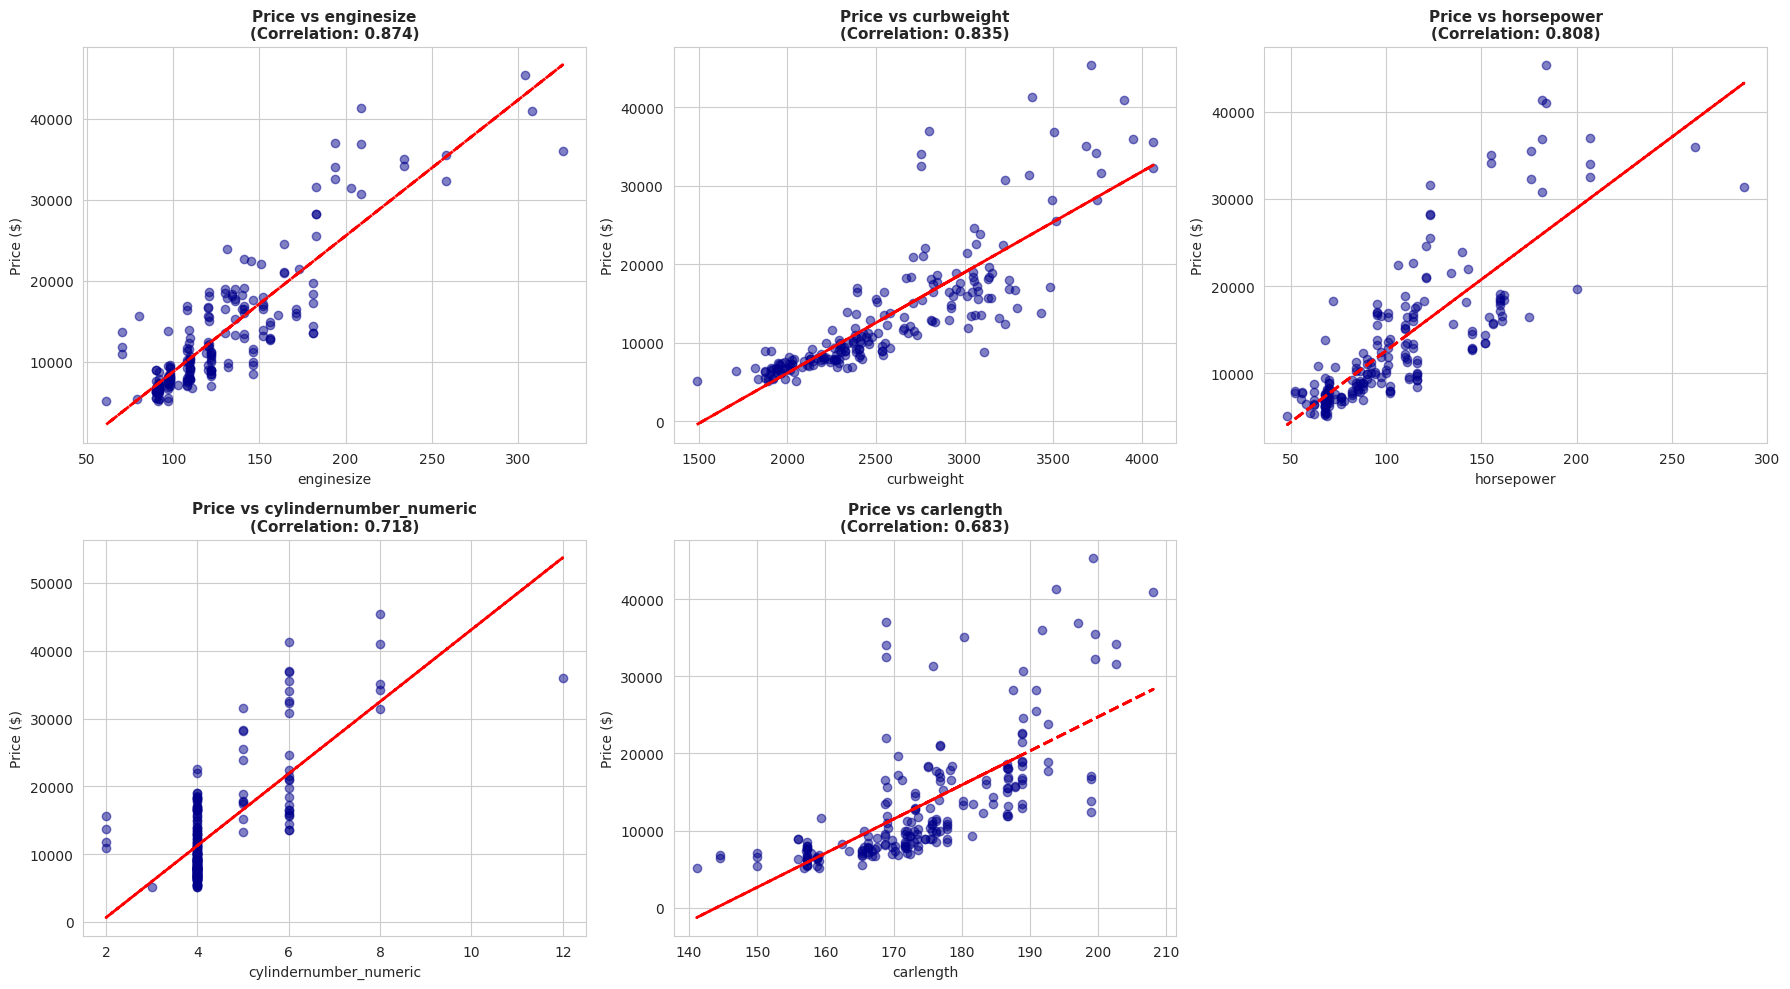

In [0]:
# Bivariate Analysis - Price vs Numerical Features
print("=" * 60)
print("BIVARIATE ANALYSIS - PRICE VS NUMERICAL FEATURES")
print("=" * 60)

# Correlation with price
numerical_cols = df_pd.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if 'ID' not in col and 'id' not in col and col != 'price']

correlations = df_pd[numerical_cols + ['price']].corr()['price'].sort_values(ascending=False)
print("\nCorrelation with Price:")
print(correlations[1:])  # Exclude price itself

# Scatter plots for top correlated features
top_features = correlations[1:6].index.tolist()  # Top 5 features

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    axes[idx].scatter(df_pd[col], df_pd['price'], alpha=0.5, color='darkblue')
    axes[idx].set_title(f'Price vs {col}\n(Correlation: {correlations[col]:.3f})', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Price ($)')
    
    # Add trend line
    z = np.polyfit(df_pd[col], df_pd['price'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_pd[col], p(df_pd[col]), "r--", linewidth=2)

# Hide empty subplot
axes[5].axis('off')

plt.tight_layout()
display(plt.show())

BIVARIATE ANALYSIS - PRICE VS CATEGORICAL FEATURES

Average Price by CarName:
                                    mean   median  count
CarName                                                 
buick regal sport coupe (turbo)  45400.0  45400.0      1
bmw x5                           41315.0  41315.0      1
buick century special            40960.0  40960.0      1
porsche boxter                   37028.0  37028.0      1
jaguar xk                        36000.0  36000.0      1
...                                  ...      ...    ...
Nissan versa                      5499.0   5499.0      1
mitsubishi mirage                 5389.0   5389.0      1
toyota corona mark ii             5348.0   5348.0      1
maxda rx3                         5195.0   5195.0      1
chevrolet impala                  5151.0   5151.0      1

[147 rows x 3 columns]

Average Price by fueltype:
                mean   median  count
fueltype                            
diesel    15838.1500  13852.5     20
gas       12999.79

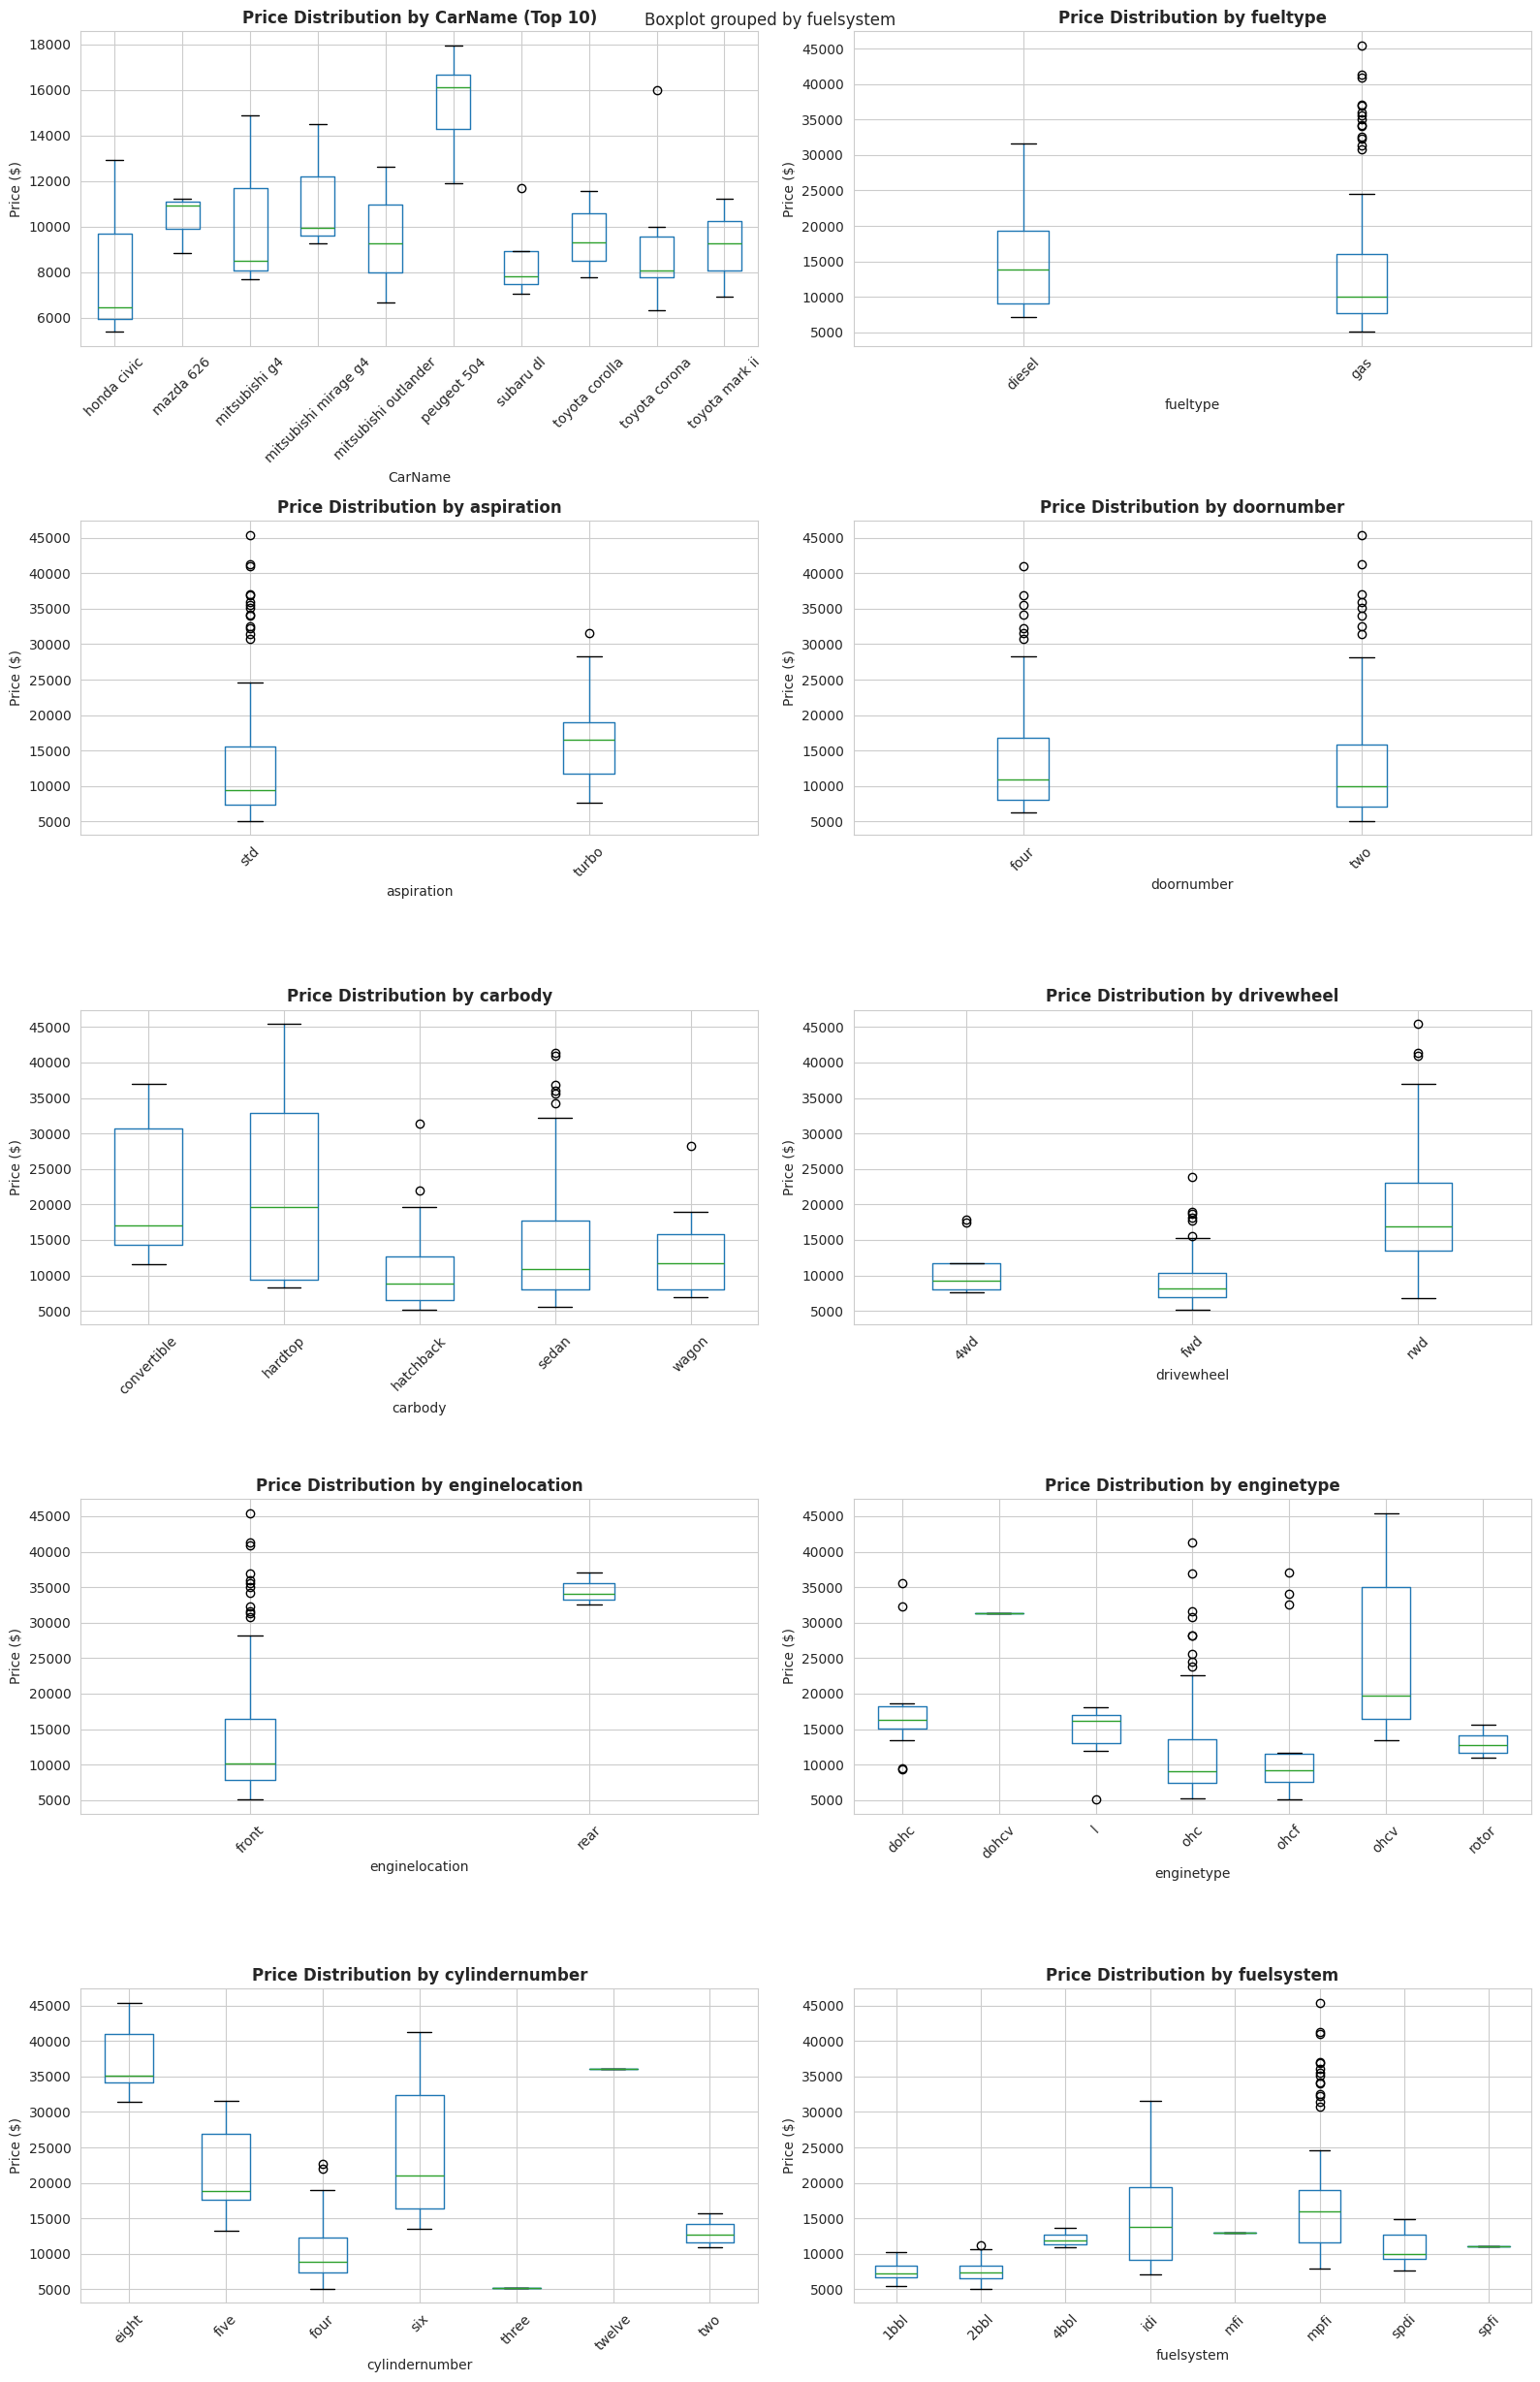

In [0]:
# Bivariate Analysis - Price vs Categorical Features
print("=" * 60)
print("BIVARIATE ANALYSIS - PRICE VS CATEGORICAL FEATURES")
print("=" * 60)

categorical_cols = df_pd.select_dtypes(include=['object']).columns

# Calculate average price by category
for col in categorical_cols:
    print(f"\nAverage Price by {col}:")
    avg_price = df_pd.groupby(col)['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    print(avg_price)

# Box plots for categorical features
num_cats = len(categorical_cols)
rows = (num_cats + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 5))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    # Handle categories with too many unique values
    if df_pd[col].nunique() <= 10:
        df_pd.boxplot(column='price', by=col, ax=axes[idx])
        axes[idx].set_title(f'Price Distribution by {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Price ($)')
        plt.sca(axes[idx])
        plt.xticks(rotation=45)
    else:
        # For categories with many values, show top 10
        top_categories = df_pd[col].value_counts().head(10).index
        df_subset = df_pd[df_pd[col].isin(top_categories)]
        df_subset.boxplot(column='price', by=col, ax=axes[idx])
        axes[idx].set_title(f'Price Distribution by {col} (Top 10)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Price ($)')
        plt.sca(axes[idx])
        plt.xticks(rotation=45)

# Hide empty subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
display(plt.show())

CORRELATION ANALYSIS

Correlation Matrix:


symboling,wheelbase,carlength,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,doornumber_numeric,cylindernumber_numeric
1.0,-0.5319536816234925,-0.35761152261729123,-0.5410381997685207,-0.2276905884774526,-0.10578970928966426,-0.13005135968493117,-0.008735140673331062,-0.17851508438647604,0.07087272404244964,0.27360624512880943,-0.03582262794554099,0.034606000711919854,-0.07997822464270359,-0.6640734518037427,-0.11312946091357079
-0.5319536816234925,1.0,0.874587475964264,0.5894347616933517,0.7763863277822105,0.5693286815396968,0.4887498752756672,0.16095904729726282,0.24978584518743374,0.35329447820540005,-0.36046874776149224,-0.47041361340548293,-0.544081923408828,0.5778155982921489,0.44735674020658506,0.33950726209426246
-0.35761152261729123,0.874587475964264,1.0,0.4910294575042151,0.8777284608306433,0.6833598726519026,0.6064543579849689,0.12953261112791242,0.15841370644020683,0.5526229673941837,-0.28724220281843926,-0.6709086615585719,-0.7046616035425505,0.6829200156779629,0.39856780380666446,0.4306719851681176
-0.5410381997685207,0.5894347616933517,0.4910294575042151,1.0,0.29557172619485034,0.06714874180270604,0.17107092150966066,-0.05530667369878668,0.2612142263199395,-0.10880205898413536,-0.3204107238101862,-0.04863962869509337,-0.10735762697679854,0.11933622657049496,0.5522079480069919,-0.013995424865187544
-0.2276905884774526,0.7763863277822105,0.8777284608306433,0.29557172619485034,1.0,0.850594073426277,0.648479748701071,0.16879003525191993,0.15136174003093056,0.7507392514434825,-0.2662431843367313,-0.757413784505601,-0.7974647922811803,0.8353048793372975,0.19737941963692154,0.6097267153698458
-0.10578970928966426,0.5693286815396968,0.6833598726519026,0.06714874180270604,0.850594073426277,1.0,0.583774327417099,0.20312858790295577,0.028971359704083287,0.8097686545377302,-0.24465982533217653,-0.6536579163114195,-0.6774699078386522,0.8741448025245117,0.020741830272750932,0.8460306875095437
-0.13005135968493117,0.4887498752756672,0.6064543579849689,0.17107092150966066,0.648479748701071,0.583774327417099,1.0,-0.05590898252008878,0.0051973387005891224,0.57367682346572,-0.25497552836873105,-0.5845317156694846,-0.5870117842417776,0.5531732367984439,0.11925822389712698,0.2313990277606355
-0.008735140673331062,0.16095904729726282,0.12953261112791242,-0.05530667369878668,0.16879003525191993,0.20312858790295577,-0.05590898252008878,1.0,0.1861101102879554,0.08093953574495318,-0.06796375316491045,-0.042144754040548675,-0.04393093044651369,0.0794430838819307,-0.011081643884114093,0.008209527238238956
-0.17851508438647604,0.24978584518743374,0.15841370644020683,0.2612142263199395,0.15136174003093056,0.028971359704083287,0.0051973387005891224,0.1861101102879554,1.0,-0.20432622618867832,-0.43574051445619716,0.32470142452073303,0.2652013891633968,0.06798350579944266,0.1778883086059824,-0.020001848743340746
0.07087272404244964,0.35329447820540005,0.5526229673941837,-0.10880205898413536,0.7507392514434825,0.8097686545377302,0.57367682346572,0.08093953574495318,-0.20432622618867832,1.0,0.13107250535631124,-0.8014561756662708,-0.7705438913729603,0.8081388225362214,-0.12694694225409828,0.6920162457155672


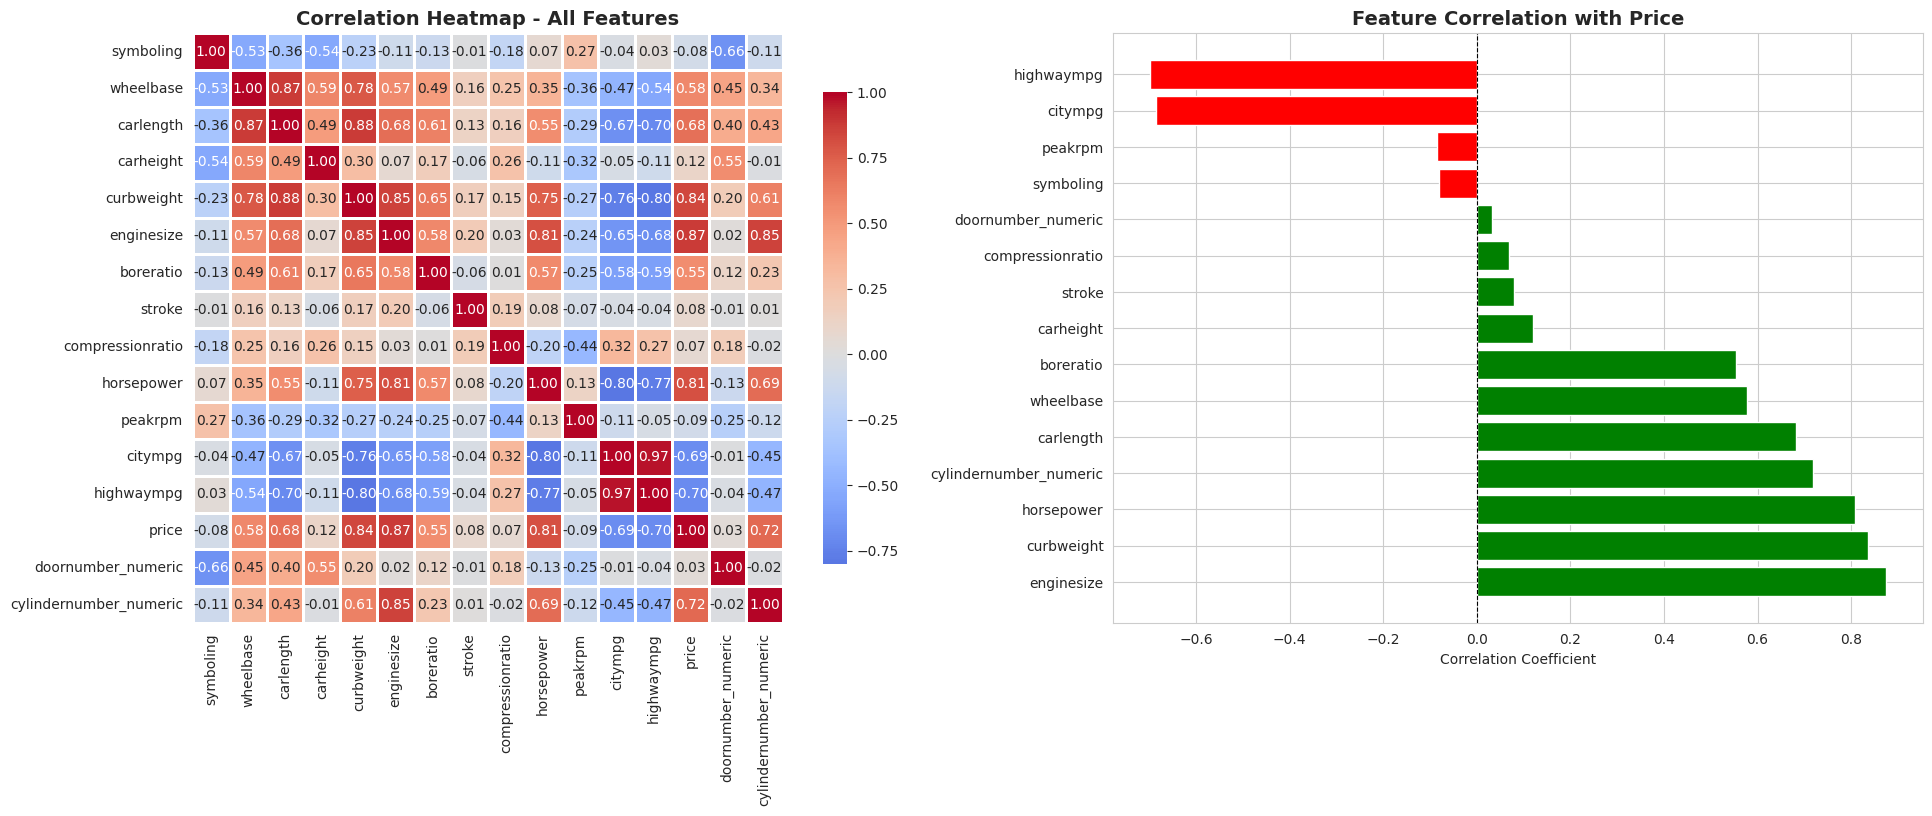



Strong Correlations (|r| > 0.7):
wheelbase <-> carlength: 0.875
wheelbase <-> curbweight: 0.776
carlength <-> curbweight: 0.878
carlength <-> highwaympg: -0.705
curbweight <-> enginesize: 0.851
curbweight <-> horsepower: 0.751
curbweight <-> citympg: -0.757
curbweight <-> highwaympg: -0.797
curbweight <-> price: 0.835
enginesize <-> horsepower: 0.810
enginesize <-> price: 0.874
enginesize <-> cylindernumber_numeric: 0.846
horsepower <-> citympg: -0.801
horsepower <-> highwaympg: -0.771
horsepower <-> price: 0.808
citympg <-> highwaympg: 0.971
price <-> cylindernumber_numeric: 0.718


In [0]:
# Correlation Analysis
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Calculate correlation matrix for numerical features
numerical_features = df_pd.select_dtypes(include=['int64', 'float64']).columns
numerical_features = [col for col in numerical_features if 'ID' not in col and 'id' not in col]

corr_matrix = df_pd[numerical_features].corr()

# Display correlation matrix
print("\nCorrelation Matrix:")
display(corr_matrix)

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Heatmap - All Features', fontsize=14, fontweight='bold')

# Price correlation bar plot
price_corr = corr_matrix['price'].sort_values(ascending=False)[1:]  # Exclude price itself
colors = ['green' if x > 0 else 'red' for x in price_corr.values]
axes[1].barh(price_corr.index, price_corr.values, color=colors)
axes[1].set_title('Feature Correlation with Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
display(plt.show())

# Identify strong correlations
print("\n\nStrong Correlations (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

ADVANCED VISUALIZATIONS

Creating pair plot for: ['enginesize', 'curbweight', 'horsepower', 'cylindernumber_numeric', 'price']


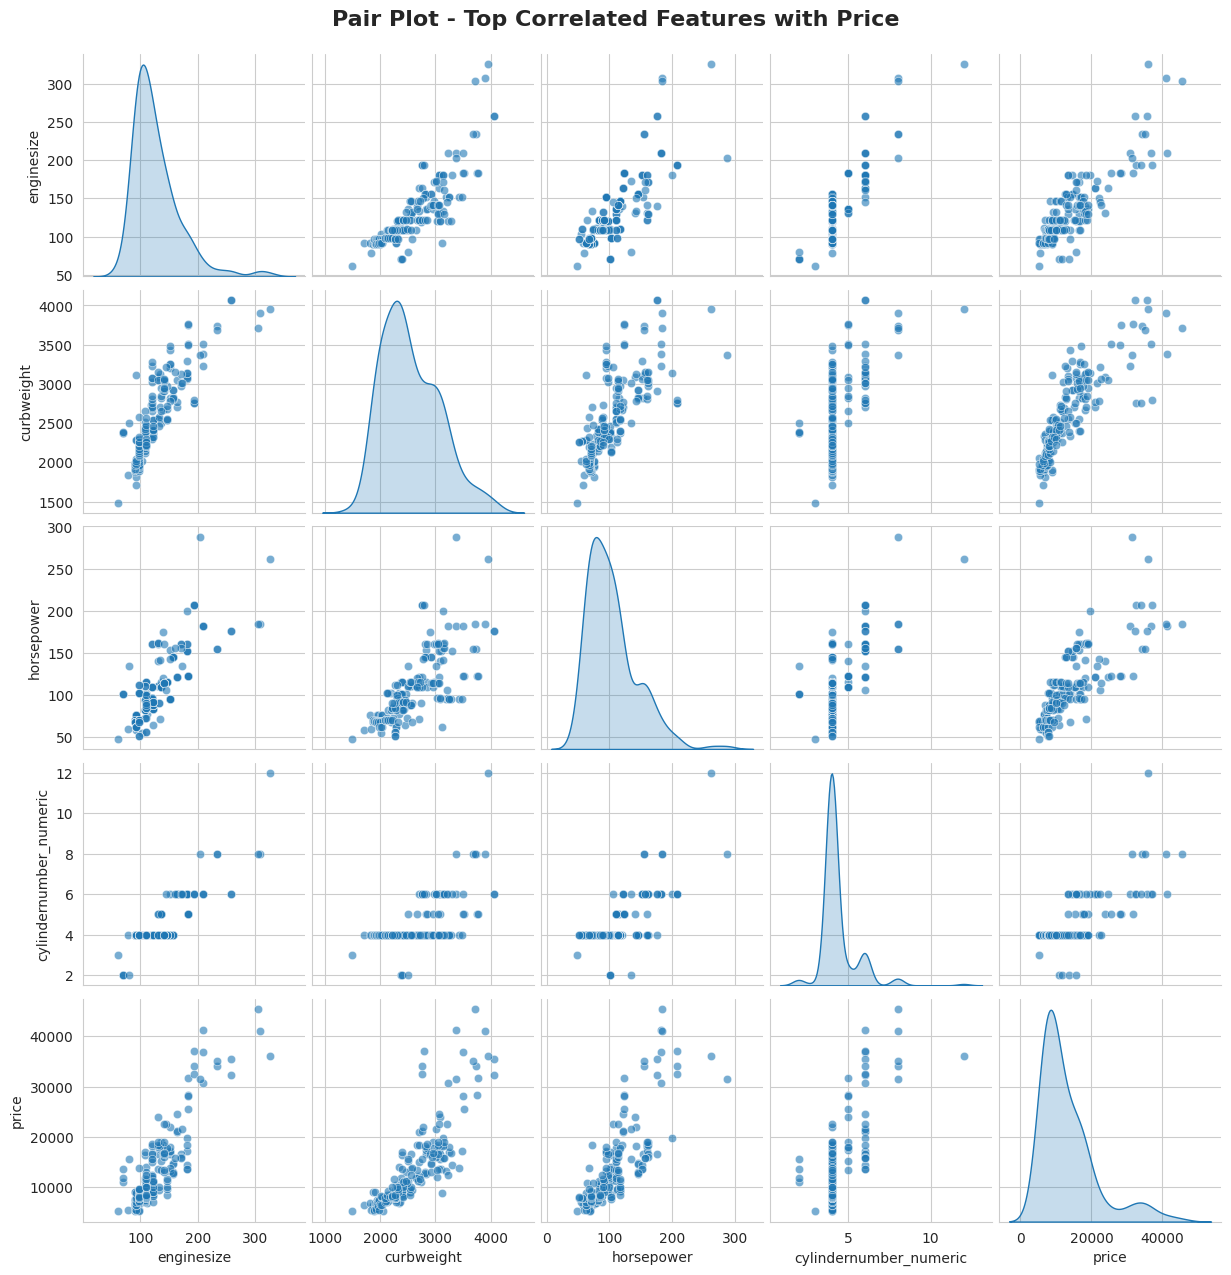


Pair plot created successfully!


In [0]:
# Advanced Visualizations - Pair Plot for Key Features
print("=" * 60)
print("ADVANCED VISUALIZATIONS")
print("=" * 60)

# Select top correlated features with price
numerical_cols = df_pd.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if 'ID' not in col and 'id' not in col and col != 'price']

correlations = df_pd[numerical_cols + ['price']].corr()['price'].abs().sort_values(ascending=False)
top_features = correlations[1:5].index.tolist() + ['price']  # Top 4 + price

print(f"\nCreating pair plot for: {top_features}")

# Pair plot
pair_plot = sns.pairplot(df_pd[top_features], diag_kind='kde', plot_kws={'alpha': 0.6})
pair_plot.fig.suptitle('Pair Plot - Top Correlated Features with Price', y=1.02, fontsize=16, fontweight='bold')
display(plt.show())

print("\nPair plot created successfully!")

In [0]:
# Key Insights Summary
print("=" * 60)
print("KEY INSIGHTS SUMMARY")
print("=" * 60)

# 1. Dataset Overview
print("\n1. DATASET OVERVIEW:")
print(f"   - Total Records: {df_pd.shape[0]}")
print(f"   - Total Features: {df_pd.shape[1]}")
print(f"   - Numerical Features: {len(df_pd.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"   - Categorical Features: {len(df_pd.select_dtypes(include=['object']).columns)}")

# 2. Target Variable (Price)
print("\n2. PRICE STATISTICS:")
print(f"   - Mean: ${df_pd['price'].mean():,.2f}")
print(f"   - Median: ${df_pd['price'].median():,.2f}")
print(f"   - Range: ${df_pd['price'].min():,.2f} - ${df_pd['price'].max():,.2f}")
print(f"   - Standard Deviation: ${df_pd['price'].std():,.2f}")
print(f"   - Skewness: {df_pd['price'].skew():.3f}")

# 3. Top Correlations
print("\n3. TOP FEATURES CORRELATED WITH PRICE:")
numerical_cols = df_pd.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if 'ID' not in col and 'id' not in col and col != 'price']
correlations = df_pd[numerical_cols + ['price']].corr()['price'].sort_values(ascending=False)
for i, (feature, corr) in enumerate(correlations[1:6].items(), 1):
    print(f"   {i}. {feature}: {corr:.3f}")

# 4. Categorical Insights
print("\n4. CATEGORICAL INSIGHTS:")
categorical_cols = df_pd.select_dtypes(include=['object']).columns
for col in categorical_cols[:3]:  # Top 3 categorical columns
    most_common = df_pd[col].mode()[0]
    count = df_pd[col].value_counts().iloc[0]
    print(f"   - Most common {col}: {most_common} ({count} cars)")

# 5. Price by Category
print("\n5. AVERAGE PRICE BY KEY CATEGORIES:")
for col in categorical_cols[:2]:  # First 2 categorical columns
    top_category = df_pd.groupby(col)['price'].mean().sort_values(ascending=False).iloc[0]
    top_name = df_pd.groupby(col)['price'].mean().sort_values(ascending=False).index[0]
    print(f"   - Highest avg price in {col}: {top_name} (${top_category:,.2f})")

print("\n" + "=" * 60)
print("EDA COMPLETE!")
print("=" * 60)

KEY INSIGHTS SUMMARY

1. DATASET OVERVIEW:
   - Total Records: 205
   - Total Features: 28
   - Numerical Features: 18
   - Categorical Features: 10

2. PRICE STATISTICS:
   - Mean: $13,276.71
   - Median: $10,295.00
   - Range: $5,118.00 - $45,400.00
   - Standard Deviation: $7,988.85
   - Skewness: 1.778

3. TOP FEATURES CORRELATED WITH PRICE:
   1. enginesize: 0.874
   2. curbweight: 0.835
   3. horsepower: 0.808
   4. cylindernumber_numeric: 0.718
   5. carlength: 0.683

4. CATEGORICAL INSIGHTS:
   - Most common CarName: peugeot 504 (6 cars)
   - Most common fueltype: gas (185 cars)
   - Most common aspiration: std (168 cars)

5. AVERAGE PRICE BY KEY CATEGORIES:
   - Highest avg price in CarName: buick regal sport coupe (turbo) ($45,400.00)
   - Highest avg price in fueltype: diesel ($15,838.15)

EDA COMPLETE!
